# Annual GHG emissions sensitivity analysis

This notebook compares annual total GHG emissions across selected model runs. Emissions are summed over all life-cycle phases and shown separately for the six policy scenarios.

In [1]:
# Configuration: edit this cell to choose runs, years, and scenario labels.
SELECTED_RUNS = [
    "annual_mileage_10000__2026-08-28_180336",
    "annual_mileage_15000__2026-08-28_180530",
    "baseline__2026-08-27_235853",
    "calibration_period_3__2026-08-28_184257",
    "calibration_period_8__2026-08-28_184435",
    "delayed_EoL__2026-08-28_185152",
    "dieselban_2030__2026-08-28_181533",
    "dieselban_2035__2026-08-28_181640",
    "emissions_year_0_accounted__2026-08-28_191314",
    "fleet_size_minus_15_growth__2026-08-28_171936",
    "fleet_size_minus_15_linear__2026-08-28_175847",
    "fleet_size_minus_8_growth__2026-08-28_165127",
    "fleet_size_minus_8_linear__2026-08-28_175713",
    "fleet_size_no_change__2026-08-28_120918",
    "fleet_size_no_change_linear__2026-08-28_173504",
    "fleet_size_plus_10_growth__2026-08-28_164418",
    "fleet_size_plus_10_linear__2026-08-28_175539",
    "fleet_size_plus_15_growth__2026-08-28_172805",
    "fleet_size_plus_15_linear__2026-08-28_180010",
    "fleet_size_plus_6_growth__2026-08-28_134153",
    "fleet_size_plus_6_linear__2026-08-28_173638",
]

START_YEAR = 2025
END_YEAR = 2050

SCENARIO_ORDER = [
    "baseline_ev_growth",
    "stronger_ev_growth",
    "abwrackpraemie",
    "verbrenneraus_2035",
    "verbrenneraus_light",
    "diesel_fahrverbot",
]
SCENARIO_LABELS = {
    "baseline_ev_growth": "Baseline",
    "stronger_ev_growth": "Accelerated baseline",
    "abwrackpraemie": "Scrappage premium",
    "verbrenneraus_2035": "Combustion-engine phase-out",
    "verbrenneraus_light": "Light combustion-engine phase-out",
    "diesel_fahrverbot": "Diesel driving ban",
}

RUN_LABELS = {
    "annual_mileage_10000": "Annual mileage: 10,000 km",
    "annual_mileage_15000": "Annual mileage: 15,000 km",
    "baseline": "Reference run",
    "calibration_period_3": "Calibration period: 3 years",
    "calibration_period_8": "Calibration period: 8 years",
    "delayed_EoL": "Delayed end-of-life (+2 years)",
    "dieselban_2030": "Diesel ban: 2030",
    "dieselban_2035": "Diesel ban: 2035",
    "emissions_year_0_accounted": "All phases in event year",
    "fleet_size_minus_15_growth": "Fleet −15% (growth)",
    "fleet_size_minus_15_linear": "Fleet −15% (linear)",
    "fleet_size_minus_8_growth": "Fleet −8% (growth)",
    "fleet_size_minus_8_linear": "Fleet −8% (linear)",
    "fleet_size_no_change": "Fleet ±0% (growth)",
    "fleet_size_no_change_linear": "Fleet ±0% (linear)",
    "fleet_size_plus_10_growth": "Fleet +10% (growth)",
    "fleet_size_plus_10_linear": "Fleet +10% (linear)",
    "fleet_size_plus_15_growth": "Fleet +15% (growth)",
    "fleet_size_plus_15_linear": "Fleet +15% (linear)",
    "fleet_size_plus_6_growth": "Fleet +6% (growth)",
    "fleet_size_plus_6_linear": "Fleet +6% (linear)",
}

In [2]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import pandas as pd


def find_final_model_dir() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        direct = candidate if candidate.name == "Final_Model" else candidate / "Final_Model"
        if (direct / "outputs" / "ghg_model").is_dir():
            return direct.resolve()
    raise FileNotFoundError(
        "Could not locate Final_Model/outputs/ghg_model from the current working directory."
    )


def run_key(run_name: str) -> str:
    return re.sub(r"__\d{4}-\d{2}-\d{2}_\d{6}$", "", run_name)


FINAL_MODEL_DIR = find_final_model_dir()
GHG_OUTPUT_DIR = FINAL_MODEL_DIR / "outputs" / "ghg_model"
REQUIRED_COLUMNS = {"Szenario", "emission_year", "phase", "emissions_tco2e"}
EXPECTED_YEARS = set(range(START_YEAR, END_YEAR + 1))

if not SELECTED_RUNS:
    raise ValueError("SELECTED_RUNS must contain at least one GHG run.")
if len(SELECTED_RUNS) != len(set(SELECTED_RUNS)):
    duplicates = sorted({name for name in SELECTED_RUNS if SELECTED_RUNS.count(name) > 1})
    raise ValueError(f"Duplicate entries in SELECTED_RUNS: {duplicates}")
if START_YEAR > END_YEAR:
    raise ValueError("START_YEAR must not be greater than END_YEAR.")

print(f"GHG output directory: {GHG_OUTPUT_DIR}")
print(f"Selected runs: {len(SELECTED_RUNS)}")

GHG output directory: C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Final_Model\outputs\ghg_model
Selected runs: 21


In [3]:
def load_run(run_name: str) -> pd.DataFrame:
    run_dir = GHG_OUTPUT_DIR / run_name
    if not run_dir.is_dir():
        raise FileNotFoundError(f"Selected GHG run directory does not exist: {run_dir}")

    manifest_path = run_dir / "run_manifest.json"
    if not manifest_path.is_file():
        raise FileNotFoundError(f"Run manifest is missing: {manifest_path}")
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if manifest.get("status") != "success":
        raise ValueError(
            f"GHG run {run_name!r} has status {manifest.get('status')!r}, not 'success'."
        )

    matches = list(run_dir.glob("*__emissions_by_phase.csv"))
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected exactly one *__emissions_by_phase.csv in {run_dir}, found {len(matches)}."
        )

    data = pd.read_csv(matches[0], sep=";", encoding="utf-8-sig")
    missing_columns = sorted(REQUIRED_COLUMNS.difference(data.columns))
    if missing_columns:
        raise ValueError(f"Missing columns in {matches[0].name}: {missing_columns}")

    data = data[["Szenario", "emission_year", "phase", "emissions_tco2e"]].copy()
    data["emission_year"] = pd.to_numeric(data["emission_year"], errors="coerce")
    data["emissions_tco2e"] = pd.to_numeric(data["emissions_tco2e"], errors="coerce")
    invalid_years = int(data["emission_year"].isna().sum())
    invalid_emissions = int(data["emissions_tco2e"].isna().sum())
    if invalid_years or invalid_emissions:
        raise ValueError(
            f"Invalid numeric values in {matches[0].name}: "
            f"{invalid_years} emission years and {invalid_emissions} emission values."
        )
    data["emission_year"] = data["emission_year"].astype(int)
    data = data[data["emission_year"].between(START_YEAR, END_YEAR)].copy()

    available_scenarios = set(data["Szenario"].dropna().unique())
    missing_scenarios = [name for name in SCENARIO_ORDER if name not in available_scenarios]
    if missing_scenarios:
        raise ValueError(f"Scenarios missing from {matches[0].name}: {missing_scenarios}")

    for scenario in SCENARIO_ORDER:
        available_years = set(data.loc[data["Szenario"].eq(scenario), "emission_year"])
        missing_years = sorted(EXPECTED_YEARS.difference(available_years))
        if missing_years:
            raise ValueError(
                f"Years missing for scenario {scenario!r} in {matches[0].name}: {missing_years}"
            )

    data["Run"] = run_name
    data["Run_key"] = run_key(run_name)
    return data


emissions_by_phase = pd.concat([load_run(name) for name in SELECTED_RUNS], ignore_index=True)
annual_total = (
    emissions_by_phase.groupby(
        ["Run", "Run_key", "Szenario", "emission_year"], as_index=False
    )["emissions_tco2e"]
    .sum()
    .rename(columns={"emissions_tco2e": "emissions_tco2e_total"})
)
annual_total["emissions_MtCO2e"] = annual_total["emissions_tco2e_total"] / 1_000_000

expected_rows = len(SELECTED_RUNS) * len(SCENARIO_ORDER) * len(EXPECTED_YEARS)
actual_rows = len(
    annual_total[annual_total["Szenario"].isin(SCENARIO_ORDER)]
)
if actual_rows != expected_rows:
    raise ValueError(
        f"Unexpected number of aggregated rows: expected {expected_rows}, found {actual_rows}."
    )

print(f"Loaded and validated {len(SELECTED_RUNS)} runs.")
print(f"Aggregated rows for the six scenarios: {actual_rows:,}")

Loaded and validated 21 runs.
Aggregated rows for the six scenarios: 3,276


In [4]:
# Fixed visual encoding. Exact colors differ from those used for powertrains, phases,
# and scenario target points in the other analysis notebooks.
RUN_STYLES = {
    "baseline": {"color": "#22223B", "linestyle": "-",  "marker": "o", "linewidth": 2.5},
    "annual_mileage_10000": {"color": "#386641", "linestyle": "--", "marker": "v"},
    "annual_mileage_15000": {"color": "#A7C957", "linestyle": "-",  "marker": "^"},
    "calibration_period_3": {"color": "#9C6644", "linestyle": "--", "marker": "<"},
    "calibration_period_8": {"color": "#DDB892", "linestyle": "-",  "marker": ">"},
    "delayed_EoL": {"color": "#8338EC", "linestyle": "--", "marker": "D"},
    "emissions_year_0_accounted": {"color": "#C77DFF", "linestyle": "-", "marker": "d"},
    "dieselban_2030": {"color": "#9D0208", "linestyle": "--", "marker": "P"},
    "dieselban_2035": {"color": "#DC2F02", "linestyle": "-",  "marker": "X"},
    "fleet_size_minus_15_growth": {"color": "#1D3557", "linestyle": "-", "marker": "s"},
    "fleet_size_minus_8_growth": {"color": "#355070", "linestyle": "-", "marker": "s"},
    "fleet_size_no_change": {"color": "#4A6FA5", "linestyle": "-", "marker": "s"},
    "fleet_size_plus_6_growth": {"color": "#6689C6", "linestyle": "-", "marker": "s"},
    "fleet_size_plus_10_growth": {"color": "#82A7D9", "linestyle": "-", "marker": "s"},
    "fleet_size_plus_15_growth": {"color": "#A9C5E8", "linestyle": "-", "marker": "s"},
    "fleet_size_minus_15_linear": {"color": "#005F73", "linestyle": "--", "marker": "h"},
    "fleet_size_minus_8_linear": {"color": "#0A7C86", "linestyle": "--", "marker": "h"},
    "fleet_size_no_change_linear": {"color": "#249EA0", "linestyle": "--", "marker": "h"},
    "fleet_size_plus_6_linear": {"color": "#52B6B0", "linestyle": "--", "marker": "h"},
    "fleet_size_plus_10_linear": {"color": "#7DCEC3", "linestyle": "--", "marker": "h"},
    "fleet_size_plus_15_linear": {"color": "#A8E2D8", "linestyle": "--", "marker": "h"},
}

missing_labels = sorted({run_key(name) for name in SELECTED_RUNS}.difference(RUN_LABELS))
missing_styles = sorted({run_key(name) for name in SELECTED_RUNS}.difference(RUN_STYLES))
if missing_labels:
    raise ValueError(f"RUN_LABELS has no labels for: {missing_labels}")
if missing_styles:
    raise ValueError(f"RUN_STYLES has no styles for: {missing_styles}")

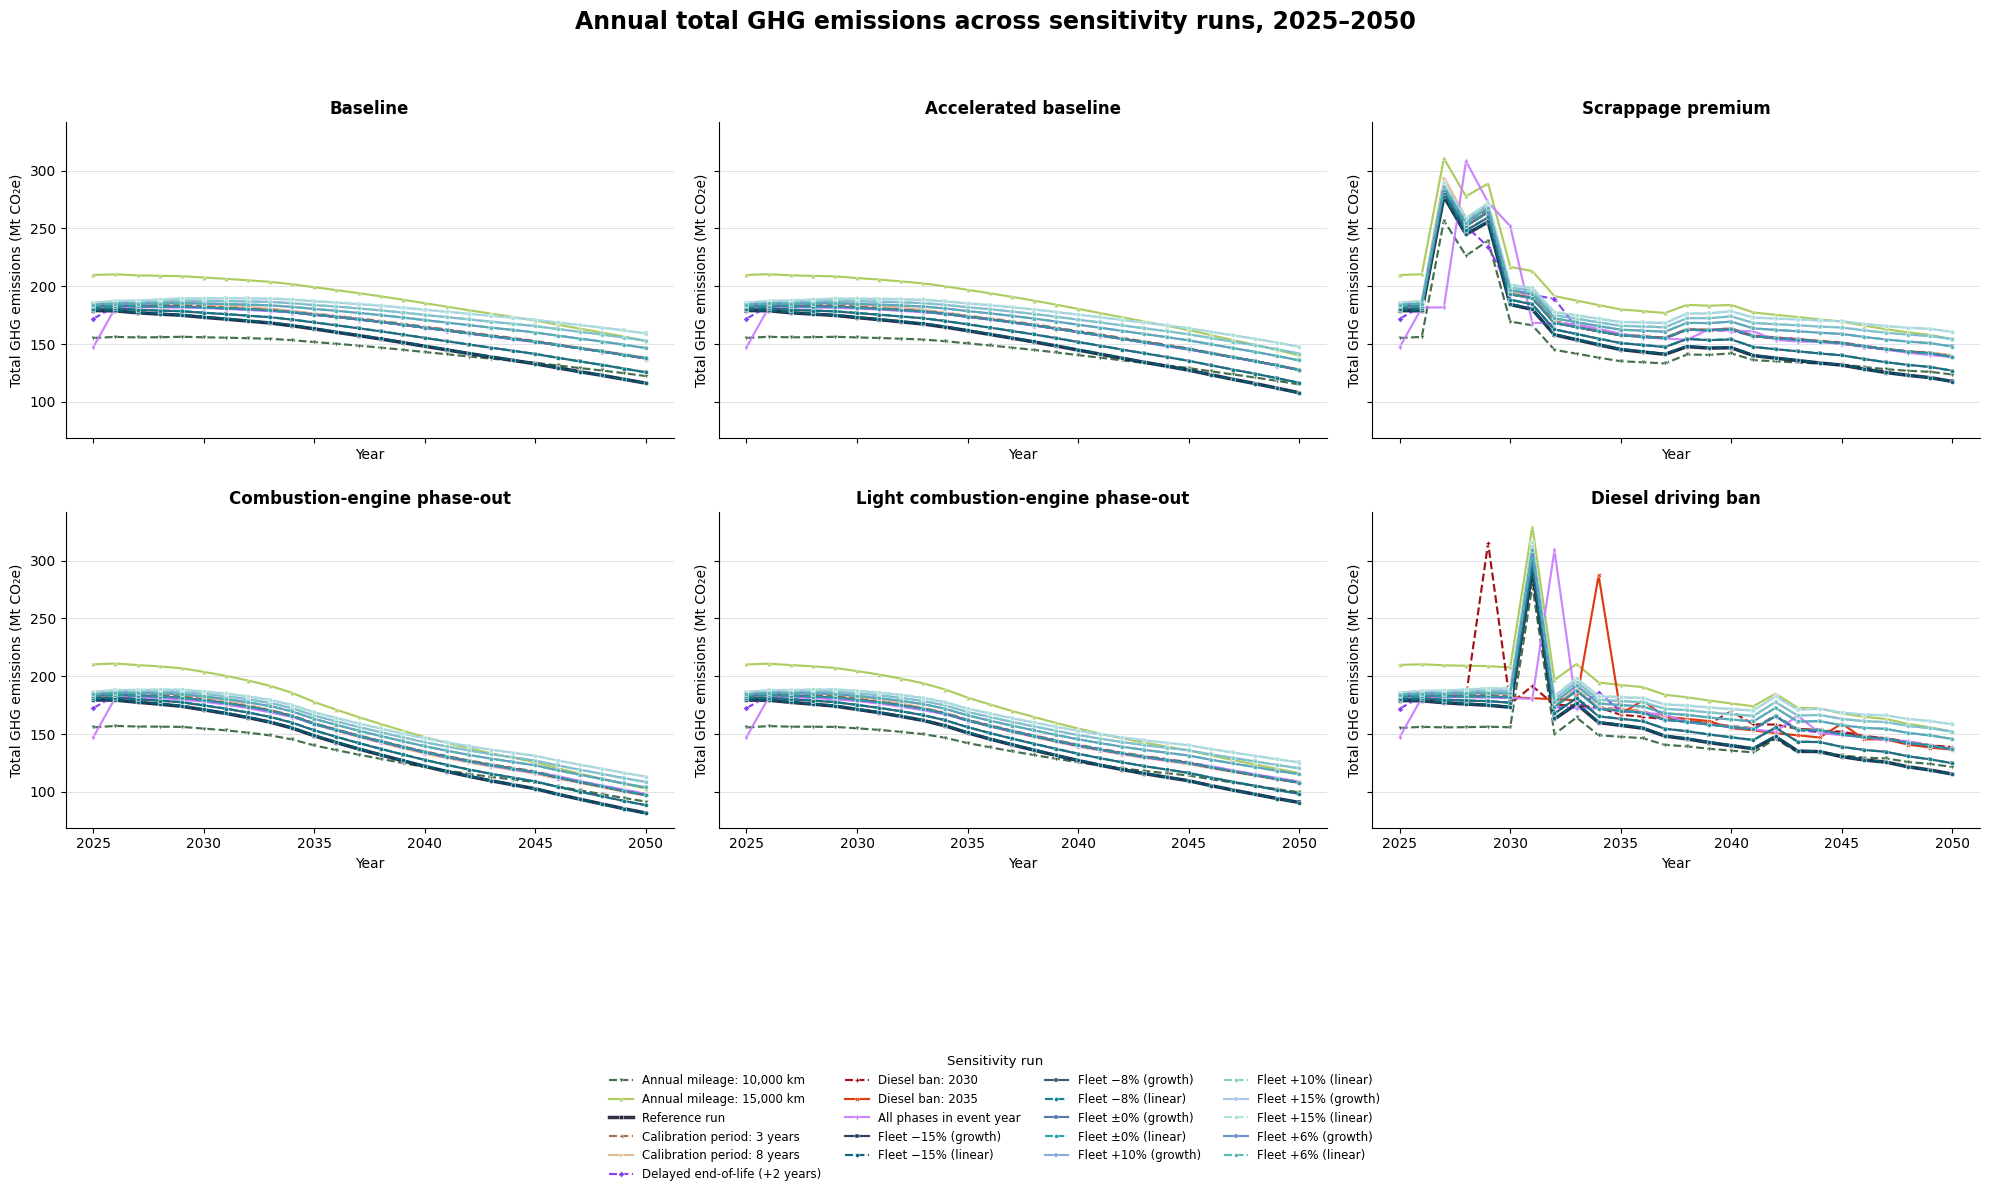

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=True, squeeze=False)
years = list(range(START_YEAR, END_YEAR + 1))

for ax, scenario in zip(axes.flat, SCENARIO_ORDER):
    for run_name in SELECTED_RUNS:
        key = run_key(run_name)
        line_data = (
            annual_total.loc[
                annual_total["Run"].eq(run_name),
                ["Szenario", "emission_year", "emissions_MtCO2e"],
            ]
            .loc[lambda frame: frame["Szenario"].eq(scenario)]
            .set_index("emission_year")["emissions_MtCO2e"]
            .reindex(years)
        )
        if line_data.isna().any():
            missing = line_data[line_data.isna()].index.tolist()
            raise ValueError(f"Missing plot values for {run_name}, {scenario}: {missing}")

        style = RUN_STYLES[key]
        ax.plot(
            years,
            line_data.values,
            label=RUN_LABELS[key],
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            linewidth=style.get("linewidth", 1.55),
            markersize=3.2,
            markeredgecolor="white",
            markeredgewidth=0.35,
            alpha=0.94,
        )

    ax.set_title(SCENARIO_LABELS[scenario], fontsize=12, fontweight="semibold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Total GHG emissions (Mt CO₂e)")
    ax.set_xticks(list(range(START_YEAR, END_YEAR + 1, 5)))
    ax.grid(axis="y", color="#D1D5DB", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles, labels, title="Sensitivity run", loc="lower center",
    ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.005), fontsize=8.5, title_fontsize=9.5,
)
fig.suptitle(
    f"Annual total GHG emissions across sensitivity runs, {START_YEAR}–{END_YEAR}",
    fontsize=17, fontweight="bold",
)
fig.tight_layout(rect=[0, 0.25, 1, 0.95], h_pad=2.0, w_pad=1.5)
plt.show()

## Cumulative total GHG emissions

The table sums annual emissions over the configured analysis period and over all life-cycle phases.

In [6]:
from IPython.display import Markdown, display

cumulative_long = (
    annual_total.loc[annual_total["Szenario"].isin(SCENARIO_ORDER)]
    .groupby(["Run", "Szenario"], as_index=False)["emissions_MtCO2e"]
    .sum()
)
cumulative_table = (
    cumulative_long.pivot(index="Run", columns="Szenario", values="emissions_MtCO2e")
    .reindex(index=SELECTED_RUNS, columns=SCENARIO_ORDER)
)

expected_shape = (len(SELECTED_RUNS), len(SCENARIO_ORDER))
if cumulative_table.shape != expected_shape:
    raise ValueError(
        f"Unexpected cumulative table shape: expected {expected_shape}, found {cumulative_table.shape}."
    )
if cumulative_table.isna().any().any():
    missing = cumulative_table.isna().stack().loc[lambda values: values].index.tolist()
    raise ValueError(f"Missing cumulative emission values for: {missing}")

# Internal reconciliation: the first table entry must equal its 26 annual values.
check_run = SELECTED_RUNS[0]
check_scenario = SCENARIO_ORDER[0]
annual_check = annual_total.loc[
    annual_total["Run"].eq(check_run) & annual_total["Szenario"].eq(check_scenario),
    "emissions_MtCO2e",
].sum()
table_check = cumulative_table.loc[check_run, check_scenario]
if abs(annual_check - table_check) > 1e-9:
    raise ValueError("Cumulative table value does not match the sum of annual emissions.")

cumulative_table.index = [RUN_LABELS[run_key(name)] for name in cumulative_table.index]
cumulative_table.columns = [SCENARIO_LABELS[name] for name in cumulative_table.columns]
cumulative_table.index.name = "Sensitivity run"
cumulative_table.columns.name = "Scenario"

display(Markdown(
    f"**Cumulative total GHG emissions, {START_YEAR}-{END_YEAR} (Mt CO2e)**"
))
display(cumulative_table.style.format(precision=2, thousands=","))

**Cumulative total GHG emissions, 2025-2050 (Mt CO2e)**

Scenario,Baseline,Accelerated baseline,Scrappage premium,Combustion-engine phase-out,Light combustion-engine phase-out,Diesel driving ban
Sensitivity run,,,,,,
"Annual mileage: 10,000 km","3,762.12","3,699.70","3,927.17","3,374.86","3,458.45","3,834.46"
"Annual mileage: 15,000 km","4,907.98","4,793.38","5,044.10","4,221.47","4,371.90","4,956.24"
Reference run,"3,977.45","3,901.48","4,126.50","3,511.13","3,612.37","4,033.01"
Calibration period: 3 years,"4,356.12","4,266.93","4,511.65","3,817.55","3,934.93","4,418.74"
Calibration period: 8 years,"4,367.98","4,275.35","4,524.25","3,805.95","3,927.48","4,426.10"
Delayed end-of-life (+2 years),"4,320.62","4,231.60","4,470.87","3,781.63","3,899.21","4,380.77"
Diesel ban: 2030,"4,335.05","4,246.54","4,485.63","3,798.16","3,915.17","4,413.39"
Diesel ban: 2035,"4,335.05","4,246.54","4,485.63","3,798.16","3,915.17","4,378.55"
All phases in event year,"4,291.81","4,200.82","4,442.13","3,751.34","3,870.16","4,353.28"


## Interpretation note

Each line represents one complete GHG model run. Values include vehicle production, battery production, use-phase, and end-of-life emissions. The cumulative table contains the sum of these phases over all years from `START_YEAR` through `END_YEAR`. Change `SELECTED_RUNS` in the first code cell to focus both the figure and table without modifying the loading, aggregation, or plotting code.